<a href="https://colab.research.google.com/github/PapiDrago/subreddit-classification/blob/main/subreddit_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive/')
!cp -r '/content/drive/MyDrive/260710-reddit' '/content/reddit/'

Mounted at /content/drive/


In [ ]:
import torch

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(DEVICE)

cuda


In [ ]:
# Exploratoty Data Analysis (EDA)

# Part 1

# We want to check if the proposed dataset in terms of csv files, is actually what they promised.
# Are there really 90'000 lines in the training portion and 10'000 in the test portion?
# The field separator character appears '|' appears only as separator field or even in text fields?
# Notice that given 5 fields we expect four '|' on each line.
from collections import Counter

path = '/content/reddit/train.csv'

pipe_counts = Counter()
n_lines = 0
examples_low = []   # lines with < 4 pipes
examples_high = []  # lines with > 4 pipes

with open(path, encoding='utf-8') as f:
    for line in f:
        line = line.rstrip('\n')
        c = line.count('|')
        pipe_counts[c] += 1
        n_lines += 1
        if c < 4 and len(examples_low) < 5:
            examples_low.append(line)
        elif c > 4 and len(examples_high) < 5:
            examples_high.append(line)

print(f"total lines: {n_lines}")
print("pipe-count distribution (pipes -> #lines):")
for k in sorted(pipe_counts):
    print(f"  {k:>3} : {pipe_counts[k]}")

print("\n--- examples with <4 pipes ---")
for e in examples_low:
    print(repr(e[:200]))

print("\n--- examples with >4 pipes ---")
for e in examples_high:
    print(repr(e[:200]))

# We have two affirmative answers to the previous two questions.



total lines: 90000
pipe-count distribution (pipes -> #lines):
    4 : 90000

--- examples with <4 pipes ---

--- examples with >4 pipes ---


In [ ]:
# Exploratory Data Analysis
# Part 2

# The goal is now to use Pandas to carry on the EDA. We are interested in how the data are distributed.

# Before actually doing it we need to preapre the dataset in order to prevent Pandas from interpreting it
# unproperly. By default Pandas treats the quote character '"' in this way. If the quote is
# found at the very beginning of a field, i.e., after the separator character then it will consider
# as text literals everything between the opening quote and the closing quote. This means that if
# among the text literals is present a delimitator, then it swallows the following field until another '"'
# is met. Hence we may have entire lines that are not interprested as a subreddit post sample.
# This problem may hide in any text field including the first one that is the subreddit field.

import csv
import pandas as pd

COLS = ['subreddit', 'num_comments', 'score', 'title', 'text']

def load(path):
    df = pd.read_csv(
        path,
        sep='|',
        header=None,
        names=COLS,
        quoting=csv.QUOTE_NONE,   # treat " and ' as ordinary characters
        keep_default_na=False,    # keep empty text as "" instead of NaN
        dtype={'num_comments': int, 'score': int,
               'title': str, 'text': str},
    )
    return df

train = load('/content/reddit/train.csv')
test  = load('/content/reddit/test.csv')

print(train.shape, test.shape)

# - - - - - - - - - - - - - -  - - - - - - - - - - - - - -

# 1. class balance
print(train['subreddit'].value_counts())

# 2. numeric ranges — score should go negative, num_comments should not
print(train[['num_comments', 'score']].describe())

# 3. body-text status — how often empty / deleted / removed?
status = train['text'].map(lambda t:
    'empty'   if t.strip() == '' else
    'deleted' if t.strip() == '[deleted]' else
    'removed' if t.strip() == '[removed]' else
    'present')
print(status.value_counts())

# 4. same status breakdown per subreddit — does it vary by topic?
print(train.assign(status=status)
           .groupby('subreddit')['status']
           .value_counts(normalize=True)
           .unstack(fill_value=0)
           .round(2))

# 1. The class samples are equally represented both in the training dataset and in the test dataset:
#    In the training set we have 9000 samples per class and in the test set we have 1000 samples per class.
#    Remember that we have 10 classes, i.e, the 10 subreddits name.
#
# 2. As expected we have always a number of comments >= 0. By looking at the boxplot we see that many posts
#    do not have any comment (this can be a good thing for the main goal of the company) and the majority of
#    them (75%) have no more than 3 comments.
#    The median post has 1 comment and a score equal to 1. This is very interesting since the average is about 16 and 180
#    resepectively. This indicates the presence of many outliers. (the mean is not a robust measure to them).
#    It is important to bear in mind that a brand new post starts with no comments and a score equal to 1 (from the
#    original poster), that it is exactly the middle post, this may mean that the majority of posts is being ignored.
#    These outliers are posts that were controversial and because of that became viral or that simply went viral
#    because contained some content that luckily made those posts emerge. This implies that the numeric features encodes
#    the virality longevity of the posts and not their belonging to a specific subreddit. Furthermore
#    the company is going to do the labeling when a post has been just created and at this time those feature values
#    won't be as important as the actual title and text content (This insight was from Claude).
#    It is also interesting to comment the 'score' field: dramatically we have no posts having a negative
#    score although it is the difference between upvotes and downvotes (positive and negative feedbacks).
#    I speculate that by default Reddit does not display a score that is below zero even if the actual score is negative.
#    Hence we may interpret a score equal to 0 as a post which was negatively-valued. However this does not help us
#    in classifying correctly a post.
#    The majority of posts (75%) have a very small score relatively to the maximum. Hence
#    we do have outliers and by comparing the two means we see that there is one order of magnitude of difference,
#    thus it may be a good idea to normalize them.
#
# 3. More than half (51451) of the post do not present any text. This suggests that those posts may had an attachment
#    as a video or a image (or even a url in the title). Also it suggests that maybe the 'text' feature will not be as
#    important as the others.
#    Some text in the 'text' field is present in only 11136 training samples. Actually by looking at point 4 it is interesting
#    to notice that 5130 samples classified as "Jokes" contains text meaning that the 46% of total samples containing text
#    in the "text" field are "Jokes" observations. Hence a classifier may be biased towards the "Jokes" class when encountering
#    text. Thus the "text" specific content may be less important than the actual presence of some kind of content.
#
# 4. Considering each label we see if the absence or the presence of text in the 'text' field is a peculiarity of any
#    class. Considering the 'Jokes' subreddit we have that the 57% (5130) of samples contain any characters in the 'text'
#    field. This portion is much bigger than the others. This does not surprise us because this subreddit has as
#    main purpose the posting of hopefully hilarious jokes. Also notice that it is the only subreddit such that
#    the 'text' field is either present, deleted or removed but not empty (this may be a subreddit policy).
#    It is not surprising neither that the 60% and 75% the of 'Art' and 'cats' subreddit posts are empty since the
#    typical post involves the uploading of one or more images about a piece of art or cats.
#    It looks surprising that 81% of 'business' posts are empty: by actually checking the subreddit it has been found
#    that a typical 'business' post has in the title a question or a link to a business related news.
#    Finally it is worth to mention there is no post in both 'news' and 'politics' subreddits that was removed by
#    the moderators of the subreddits. Also in both of them the majority present an empty 'text' field: this is due
#    to having directly in the title a link to the news.

'''
This is a multiline
comment.
'''

'''
Output obtained from the test set:
(90000, 5) (10000, 5)
subreddit
news        1000
politics    1000
gaming      1000
Jokes       1000
movies      1000
Art         1000
Music       1000
anime       1000
business    1000
cats        1000
Name: count, dtype: int64
       num_comments        score
count  10000.000000  10000.00000
mean      14.536200    174.89800
std      152.634619   1759.15391
min        0.000000      0.00000
25%        0.000000      1.00000
50%        1.000000      1.00000
75%        3.000000      7.00000
max    10050.000000  55823.00000
text
empty      5654
deleted    1876
present    1266
removed    1204
Name: count, dtype: int64
status     deleted  empty  present  removed
subreddit
Art           0.34   0.58     0.01     0.07
Jokes         0.16   0.00     0.57     0.26
Music         0.28   0.50     0.06     0.15
anime         0.19   0.28     0.31     0.22
business      0.01   0.82     0.01     0.15
cats          0.19   0.74     0.05     0.02
gaming        0.20   0.57     0.15     0.08
movies        0.14   0.52     0.10     0.24
news          0.13   0.87     0.00     0.00
politics      0.23   0.77     0.00     0.00
'''


(90000, 5) (10000, 5)
subreddit
politics    9000
Music       9000
news        9000
business    9000
gaming      9000
anime       9000
Jokes       9000
cats        9000
movies      9000
Art         9000
Name: count, dtype: int64
       num_comments          score
count  90000.000000   90000.000000
mean      16.137744     180.785089
std      346.276205    2008.296609
min        0.000000       0.000000
25%        0.000000       1.000000
50%        1.000000       1.000000
75%        3.000000       7.000000
max    91283.000000  103279.000000
text
empty      51451
deleted    16609
present    11136
removed    10804
Name: count, dtype: int64
status     deleted  empty  present  removed
subreddit                                  
Art           0.32   0.60     0.01     0.07
Jokes         0.16   0.00     0.57     0.27
Music         0.26   0.54     0.06     0.14
anime         0.20   0.27     0.30     0.22
business      0.01   0.81     0.02     0.16
cats          0.18   0.75     0.05     0.02
gaming

'\nOutput obtained from the test set:\n(90000, 5) (10000, 5)\nsubreddit\nnews        1000\npolitics    1000\ngaming      1000\nJokes       1000\nmovies      1000\nArt         1000\nMusic       1000\nanime       1000\nbusiness    1000\ncats        1000\nName: count, dtype: int64\n       num_comments        score\ncount  10000.000000  10000.00000\nmean      14.536200    174.89800\nstd      152.634619   1759.15391\nmin        0.000000      0.00000\n25%        0.000000      1.00000\n50%        1.000000      1.00000\n75%        3.000000      7.00000\nmax    10050.000000  55823.00000\ntext\nempty      5654\ndeleted    1876\npresent    1266\nremoved    1204\nName: count, dtype: int64\nstatus     deleted  empty  present  removed\nsubreddit\nArt           0.34   0.58     0.01     0.07\nJokes         0.16   0.00     0.57     0.26\nMusic         0.28   0.50     0.06     0.15\nanime         0.19   0.28     0.31     0.22\nbusiness      0.01   0.82     0.01     0.15\ncats          0.19   0.74     0.

In [ ]:
# Feature selection and extraction
#
# Let's make some consideration about the tags [deleted] and [removed]. They are considered possible words in the body of the 'text' field.
# In the training set 27413 posts are tagged [deleted] or [removed] (about 30%) and we've seen that given the subreddit the amount of these
# specific samples is different.
# If we were to model the 'text' field with bag-of-words we would have a vocabulary containing also those tags and then we would
# estimate the conditional probability of each word given each subreddit and as we have already observed we would've different probability
# estimates given different classes. To be clear, let's make the following example:
# P([removed] | 'news') = 0, P([removed] | 'Jokes') != 0.
# Hence these tags are clearly informative.
# However the goal of the company is to assign a brand new post to a specific subreddit. In this brand new post it is impossible that
# '[deleted]' and '[removed]' appear. To understand why it is important to know why those specific tags may appear in the body of the 'text' field.
# '[deleted]' means that the original poster themselves decided to take down its own post.
# '[removed]' means that the post is taken down by the moderators (or the admins) of the subreddit.
# Both these actions are performed after the posting into a subreddit and for sure those tags are not written in the body of the 'text' field
# by the original poster themselves but they describe the status of a post. Hence if we wish to retain these tags in our classification models
# it is better to make a new categorical feature describing the status of a post. This feature can take the values "empty", "deleted", "present",
# "removed".
# As we hinted, however the status of a post may be not helpful at all in assigning a subreddit to a brand new post because they are posterior
# to the original posting. Maybe the status 'removed' may be helpful for the company if it wants to be sure that its posts are not likely to
# be removed, however the scope of the requested model is not minimizing the risk of a post being removed.
# In other terms the model may learn removed-ness by subreddit and this is not helpful at all at inference time when we need to
# assign the post. For this final reason I decide to discard the 'status' feature from the final model. This feature will be however used
# in order to compare the models.

# Earlier we've said that the features "num_comments" and "score" "encode the virality longevity of the posts and not
# their belonging to a specific subreddit. Furthermore the company is going to do the labeling when a post has been just
# created and at this time those feature values won't be as important as the actual title and text content".
# From this consideration we may think to use in the final model only the features "title" and "text" since they are the only
# ones involved in the creation of a post and intuitively their contents has to be afferent to the subreddit topic.
#
#
#

In [ ]:
# Multinomial Logistic Regression
# It is a discriminative method: it models directly the posterior probability of having a class given a sample.
# It focuses on piece-wise linear decision boundaries separating all the classes.
# The model will be identified by a learnable weight matrix that will have as many rows as the number of classes.
# Thus we have weights dedicated to each class.
# At inference time, a sample is assigned to the class corresponding to the largest estimated posterior probability.
# The training phase will be based on minimizing the average cross-entropy function with a L2 regularization term.
# To exploit the regularization is needed to normalize "num_comments" and "score" which are on different scales.
# This is due to the fact that a smaller-ranged feature will have bigger weights compared to the larger-ranged one.
# L2 regularization will try to contain the values of the biggest weight in order to distribute the weights more
# uniformly among the features, hence it will focus (penalyze) mostly on the weights corresponding to the feature on a smaller
# scale.
#
# Of course the feature vector x needs to contain numerical values. Hence we need to find a suitable representation
# for 'title' and 'text'. We decided to use the bag-of-word representation in which a document (any ensemble of words)
# is represented by a vector containing the counts of the words appearing in the document that belong to a vocabulary.
# This vocabulary may be composed arbitrarily or learnt from the training set. We chose to learn it from the data,
# and furthermore we chose to have a unique vocabulary both for 'title' and for 'text'. This design decision implies merging
# the two features in one (we are concatenating the values of the features, i.e., title + " " + text).
# The counts vector repesenting the 'text' will be the result of the onehot vectors given by each word (belonging
# to the vocabulary) appearing in the post.
# Before learning the vocabulary from the data, we need to get rid of the tags '[removed]' and '[deleted]' from the 'text'
# in order to prevent learning removed-ness and delete-ness.

import re
import numpy as np
from sklearn.feature_extraction.text import CountVectorizer

TAG_RE = re.compile(r'\[deleted\]|\[removed\]')
URL_RE = re.compile(r'http\S+|www\.\S+')

def make_text(df):
    body = df['text'].map(lambda t: TAG_RE.sub(' ', t))
    combined = (df['title'].fillna('') + ' ' + body)
    combined = combined.map(lambda s: URL_RE.sub(' ', s))   # strip URLs. It removed about 200 tokens.
    return combined.str.strip()


train_text = make_text(train)
test_text  = make_text(test)

# Building the vocabulary

vectorizer = CountVectorizer(
    lowercase=True,      # collapse Case differences -> smaller vocab
    min_df=5,            # drop words appearing in <5 posts (typos, junk)
    token_pattern=r'(?u)\b\w\w+\b',   # default: 2+ char tokens, drops punctuation
)

X_train_text = vectorizer.fit_transform(train_text)   # fit on TRAIN only
X_test_text  = vectorizer.transform(test_text)         # transform test with train vocab

print("train text matrix:", X_train_text.shape)
print("test  text matrix:", X_test_text.shape)
print("vocabulary size:", len(vectorizer.vocabulary_))

#
# Also we have the status feature (??????????????????????)
#
#
#
#

train text matrix: (90000, 17034)
test  text matrix: (10000, 17034)
vocabulary size: 17034


In [ ]:
# Let's print some words contained in the vocabulary.
# They are in lexicographical order meaning that in the first positions there are the numbers.
# Tokens like '1080p' are important because they are informative regarding the particular subreddit.
# It is highly-unlikely that we would find '1080p' in post of the "Jokes" subreddit.
# However URLs are just noise and they have been removed since they are post specific.

print(vectorizer.get_feature_names_out()[:50])
print(vectorizer.get_feature_names_out()[8000:8050])

['00' '000' '007' '0079' '00s' '01' '02' '03' '04' '05' '06' '07' '08'
 '09' '10' '100' '1000' '1000x1000' '1000x1000px' '100k' '101' '102'
 '1024' '103' '104' '105' '1050' '106' '1060' '108' '1080' '1080p'
 '1080x1080' '1080x1350' '1080x1350px' '1080x1920' '109' '10i' '10pm'
 '10th' '10x' '10x10' '10x14' '10x8' '11' '110' '111' '112' '113' '115']
['izuku' 'jabs' 'jack' 'jackass' 'jacket' 'jackets' 'jackie' 'jackson'
 'jacob' 'jade' 'jadi' 'jagger' 'jail' 'jailbreak' 'jailed' 'jaipur'
 'jakarta' 'jake' 'jam' 'jamaica' 'jamaican' 'jamal' 'jamb' 'james'
 'jamie' 'jamil' 'jams' 'jan' 'jane' 'janet' 'janitors' 'janta' 'january'
 'japan' 'japanese' 'jar' 'jared' 'jarvis' 'jasmine' 'jason' 'jasper'
 'java' 'jaw' 'jaws' 'jax' 'jay' 'jazz' 'jazzy' 'jc' 'je']


In [ ]:
# The values in the fields 'num_comments' and 'score' are normalized in the following way:
# i) to mitigate the impact of outliers we take the natural log of our data;
# ii) the training data are standardized meaning that they are demeaned and scaled to unit variance;
# iii) the test data are demeaned and scaled using the mean and the variance of the training data.

# Now 'num_comments' and 'score' are also on a common scale.

from sklearn.preprocessing import StandardScaler

def numeric_block(df):
    return np.log1p(df[['num_comments', 'score']].to_numpy(dtype=float))

num_train_raw = numeric_block(train)
num_test_raw  = numeric_block(test)

scaler = StandardScaler()
num_train = scaler.fit_transform(num_train_raw)   # fit on TRAIN
num_test  = scaler.transform(num_test_raw)         # apply to test

print("numeric train:", num_train.shape, "numeric test:", num_test.shape)
print("means after scaling (train ~0):", num_train.mean(axis=0).round(3))
print("stds  after scaling (train ~1):", num_train.std(axis=0).round(3))
print("means after scaling (test):", num_test.mean(axis=0).round(3))
print("stds  after scaling (test):", num_test.std(axis=0).round(3))

numeric train: (90000, 2) numeric test: (10000, 2)
means after scaling (train ~0): [-0.  0.]
stds  after scaling (train ~1): [1. 1.]
means after scaling (test): [-0.001 -0.002]
stds  after scaling (test): [0.997 1.011]


In [ ]:
# In order to obtain the feature vector we need to concatenate the the numerical representations of text features with the numerical ones.
# In total the feature vector contains 17034 + 2 features. The first are very sparse and the second are dense.
# Sparse in the sense that if we consider a sample, i.e., a Reddit post, it won't contain all the words belonging to the vocabulary,
# it will be mostly a vector of zeros.
# In total we have 1 703 600 000 (17036*100000) numbers. If we use 8 bytes to store each one of them, we need nearly 12.69 GB of RAM
# (1 703 600 000 * 8 bytes / 2**30)
# and this may be unfortunate because the system RAM offered by the free tier
# of Google Colab amounts to 12.7 GB.
# We need to store only the non-zero values.
# The following snippet gives an idea about how much the training set is sparce.
nnz = X_train_text.nnz # number of stored non-zeros
total = X_train_text.shape[0] * X_train_text.shape[1]
print(f"non-zeros: {nnz:,}")
print(f"density: {nnz/total:.4%}")
print(f"sparse memory ≈ {nnz * 12 / 1e6:.0f} MB")   # ~12 bytes per nnz (value + indices)


# We are going to store both the training set and the test set matrices in
# CSR (compressed sparse row) format.

non-zeros: 1,173,009
density: 0.0765%
sparse memory ≈ 14 MB


In [ ]:
from scipy.sparse import hstack, csr_matrix

def build_features(X_text, num_block, status_block=None):
    """Concatenate sparse text + dense numeric (+ optional status) into one sparse matrix."""
    parts = [X_text, csr_matrix(num_block)]
    if status_block is not None:
        parts.append(csr_matrix(status_block))
    return hstack(parts, format='csr')

# the honest baseline variants
X_train_txt   = X_train_text                                   # text only
X_test_txt    = X_test_text

X_train_num   = build_features(X_train_text, num_train)        # text + numeric
X_test_num    = build_features(X_test_text,  num_test)

print("text only:   ", X_train_txt.shape)
print("text+numeric:", X_train_num.shape)   #17036 columns

text only:    (90000, 17034)
text+numeric: (90000, 17036)


In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_train = le.fit_transform(train['subreddit'])
y_test  = le.transform(test['subreddit'])

print("classes:", list(le.classes_))
print("y_train shape:", y_train.shape)

classes: ['Art', 'Jokes', 'Music', 'anime', 'business', 'cats', 'gaming', 'movies', 'news', 'politics']
y_train shape: (90000,)


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score

def train_eval(Xtr, ytr, Xte, yte, label):
    clf = LogisticRegression(C=1.0, max_iter=1000, n_jobs=-1)
    clf.fit(Xtr, ytr)

    train_pred = clf.predict(Xtr)
    test_pred  = clf.predict(Xte)

    train_acc = accuracy_score(ytr, train_pred)
    test_acc  = accuracy_score(yte, test_pred)
    test_f1   = f1_score(yte, test_pred, average='macro')

    print(f"{label:20s}  train_acc={train_acc:.4f}  "
          f"test_acc={test_acc:.4f}  test_macroF1={test_f1:.4f}")
    return clf

clf_txt = train_eval(X_train_txt, y_train, X_test_txt, y_test, "LR text-only")
clf_num = train_eval(X_train_num, y_train, X_test_num, y_test, "LR text+numeric")

LR text-only          train_acc=0.8833  test_acc=0.7641  test_macroF1=0.7643
LR text+numeric       train_acc=0.8930  test_acc=0.7833  test_macroF1=0.7837


In [ ]:
# It takes 8 mins to run. Beware.

# The multinomial logistic regression overfits the training set.

# We try to see if the culprit is C the inverse of the penalty strength
# (regularization coefficient).
# We apply grid search. a model selection tecnique to
# see if there are better values of C.
# NB we are using validation set split from the training set.
# It is not the culprit since the best C remains 1.

from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression

param_grid = {'C': [0.01, 0.03, 0.1, 0.3, 1.0, 3.0, 10.0]}

grid = GridSearchCV(
    LogisticRegression(max_iter=1000, n_jobs=-1),
    param_grid,
    cv=5,                      # 5-fold CV within the training set
    scoring='accuracy',
    n_jobs=-1,
)
grid.fit(X_train_num, y_train)   # text+numeric variant

print("best C:", grid.best_params_['C'])
print("best CV accuracy:", round(grid.best_score_, 4))

# now evaluate the tuned model on the untouched test set
best = grid.best_estimator_
train_acc = best.score(X_train_num, y_train)
test_acc  = best.score(X_test_num,  y_test)
print(f"tuned  train_acc={train_acc:.4f}  test_acc={test_acc:.4f}")

best C: 1.0
best CV accuracy: 0.7733
tuned  train_acc=0.8930  test_acc=0.7833


In [ ]:
# Let's try to tune the vocabulary length.
# It is very likely that the main reason of overfitting
# is the large number of parameters since it depends on
# our large number of features.
# Diminishing the number of tokens improves the generalization
# capability of the model at the cost of loosing accuracy
# in the training.
# However it starts to emerge a slight underfitting:
# we are cutting useful words.
# The highest test accuracy is obtained when we overfits.
# We are going to lock the vocabulary size obtained with
# min_df=10 because we obtain almost the exact best results
# but with a lighter model. Even with min_df=10, the best C is 1.

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from scipy.sparse import hstack, csr_matrix

def build(X_text_tr, X_text_te):
    Xtr = hstack([X_text_tr, csr_matrix(num_train)], format='csr')
    Xte = hstack([X_text_te, csr_matrix(num_test)],  format='csr')
    return Xtr, Xte

for min_df in [5, 10, 20, 50, 100]:
    vec = CountVectorizer(lowercase=True, min_df=min_df,
                          token_pattern=r'(?u)\b\w\w+\b')
    Xtr_t = vec.fit_transform(train_text)
    Xte_t = vec.transform(test_text)
    Xtr, Xte = build(Xtr_t, Xte_t)

    clf = LogisticRegression(C=1.0, max_iter=1000, n_jobs=-1)
    clf.fit(Xtr, y_train)
    tr = accuracy_score(y_train, clf.predict(Xtr))
    te = accuracy_score(y_test,  clf.predict(Xte))
    print(f"min_df={min_df:4d}  vocab={len(vec.vocabulary_):6d}  "
          f"train={tr:.4f}  test={te:.4f}  gap={tr-te:.4f}")

min_df=   5  vocab= 17034  train=0.8930  test=0.7833  gap=0.1097
min_df=  10  vocab= 10456  train=0.8728  test=0.7760  gap=0.0968
min_df=  20  vocab=  6436  train=0.8440  test=0.7681  gap=0.0759
min_df=  50  vocab=  3124  train=0.7916  test=0.7447  gap=0.0469
min_df= 100  vocab=  1683  train=0.7404  test=0.7135  gap=0.0269


In [ ]:
vectorizer = CountVectorizer(
    lowercase=True,
    min_df=10,
    token_pattern=r'(?u)\b\w\w+\b',
)
X_train_text = vectorizer.fit_transform(train_text)   # train_text already has tags + URLs stripped
X_test_text  = vectorizer.transform(test_text)
print("vocab:", len(vectorizer.vocabulary_))          # expect ~10456

vocab: 10456


In [ ]:
# Let's evaluate the Multinomial Logistic Regression Model
# also with the 'status' feature. We are going to use
# a onehot encoding to get a numerical representation
# of it.

from sklearn.preprocessing import OneHotEncoder

def status_of(df):
    def classify(t):
        s = t.strip()
        if s == '':          return 'empty'
        if s == '[deleted]':  return 'deleted'
        if s == '[removed]':  return 'removed'
        return 'present'
    return df['text'].map(classify).to_numpy().reshape(-1, 1)

status_train_raw = status_of(train)
status_test_raw  = status_of(test)

ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=True)
status_train = ohe.fit_transform(status_train_raw)   # fit on TRAIN
status_test  = ohe.transform(status_test_raw)
print("status categories:", ohe.categories_[0])       # 4 columns

status categories: ['deleted' 'empty' 'present' 'removed']


In [ ]:
def stack(*blocks):
    return hstack([csr_matrix(b) if not hasattr(b, 'tocsr') else b
                   for b in blocks], format='csr')

variants = {
    'text':                (X_train_text, X_test_text),
    'text+numeric':        (stack(X_train_text, num_train),
                            stack(X_test_text,  num_test)),
    'text+status':         (stack(X_train_text, status_train),
                            stack(X_test_text,  status_test)),
    'text+numeric+status': (stack(X_train_text, num_train, status_train),
                            stack(X_test_text,  num_test,  status_test)),
}

for name, (Xtr, Xte) in variants.items():
    train_eval(Xtr, y_train, Xte, y_test, name)

text                  train_acc=0.8600  test_acc=0.7581  test_macroF1=0.7584
text+numeric          train_acc=0.8728  test_acc=0.7760  test_macroF1=0.7764
text+status           train_acc=0.8756  test_acc=0.7768  test_macroF1=0.7770
text+numeric+status   train_acc=0.8877  test_acc=0.7947  test_macroF1=0.7950


In [ ]:
# Now let's analyze our multinomial logistic regression model that uses
# both the text and the numeric features

import numpy as np
from sklearn.linear_model import LogisticRegression

Xtr = variants['text+numeric'][0]
Xte = variants['text+numeric'][1]

clf = LogisticRegression(C=1.0, max_iter=1000, n_jobs=-1)
clf.fit(Xtr, y_train)

proba = clf.predict_proba(Xte)          # (10000, 10) class probabilities
pred  = proba.argmax(axis=1)
classes = le.classes_                    # names in index order

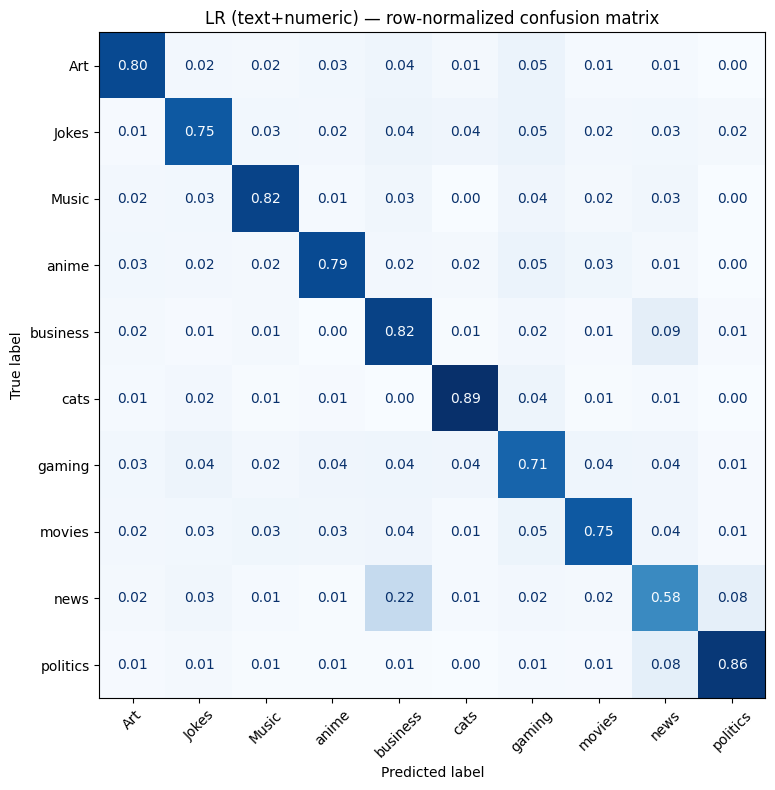

In [ ]:
# Confusion Matrix

# Multinomial Logistic Regression: 'cats' posts were the ones
# that were predicted corrected the most (89%).
# Also the other classes were predicted correctly for the
# most part (avg 78%). The exception is the class "news"
# (classified correctly 58% of the times) being misclassified
# 22% of the time with the class "business". This can be explained
# by the facts that the typical posts of related to those two
# subreddits follows the same structure: title + empty body and
# that financial news are related also to the "business"
# subreddit. However it is not true that contrary: "business" posts
# are misclassified with "news" post only % of the times.
# This is explained by the fact the vocabulary words related to
# "business" posts are more specific and thus carry more weight
# when they appear in a post towards the "business" subreddit
# while a news post related to economy has not clear signals that
# distinguishes it from a "business" post.
# "gaming" is the second misclassified class (71% of the times is
# predicted correctly). However the errors are almost evenly distributed
# among the other classes. This may be explained by the fact that "gaming"
# concerns many aspects: often a movie gets adpated by a videogame; the news
# of a gaming company acquiring another ones can be related to business and
# so on.

from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

cm = confusion_matrix(y_test, pred, normalize='true')
fig, ax = plt.subplots(figsize=(9, 8))
ConfusionMatrixDisplay(cm, display_labels=classes).plot(
    ax=ax, cmap='Blues', values_format='.2f', xticks_rotation=45, colorbar=False)
plt.title('LR (text+numeric) — row-normalized confusion matrix')
plt.tight_layout()
plt.show()

In [ ]:
# The 12 top-words for each classes.
# By looking at the classes that were predicted correctly the most, we see
# that the corresponding top-words are very class-specific. For instance
# the most heavy words for "cats" are related cat words, and this holds for all
# the subreddits with the exception of the "news" one where we cannot find coherent words
# with the exception of 'news' itself.
# In fact there we see a lot of foreign words and also the word 'mueller' that is
# a top word also for "politics" and this may explain the 8% misclassification rate.
#

feat_names = vectorizer.get_feature_names_out()
vocab_n = len(feat_names)                 # text columns; numeric are the trailing 2

def top_words(clf, class_idx, k=12):
    coefs = clf.coef_[class_idx, :vocab_n]   # text weights only
    top = np.argsort(coefs)[-k:][::-1]
    return [(feat_names[i], round(coefs[i], 3)) for i in top]

for i, name in enumerate(classes):
    words = ", ".join(w for w, _ in top_words(clf, i))
    print(f"{name:10s}: {words}")
'''
Output of the non-stemmed version
Art       : digital, acrylic, watercolor, graphite, acrylics, pencil, canvas, pencils, a4, charcoal, photoshop, ink
Jokes     : joke, jokes, walks, bar, invented, hitler, pedophiles, cow, knock, girlfriend, dick, wife
Music     : rock, punk, folk, pop, electronic, hiphop, indie, metal, alternative, classical, rap, hop
anime     : anime, amv, crunchyroll, waifu, chan, isekai, evangelion, pv, animes, geass, manga, funimation
business  : march, business, slab, ipo, printing, businesses, gartenhaus, companies, benefits, ozure, slack, nyc
cats      : cats, cat, kitten, kitty, kittens, kitties, catnip, meow, meet, fluff, litter, cute
gaming    : gaming, fortnite, gamers, sekiro, games, borderlands, gta, gamer, pubg, xbox, skyrim, gameplay
movies    : movies, x264, shazam, movie, avi, films, cinema, hdtv, film, mcu, hollywood, trailer
news      : rokambola, 방탄소년단, jakarta, fos, islam, पर, khách, arrests, malang, cookies, mueller, news
politics  : trump, mueller, biden, aoc, politics, democrats, gannavaram, climate, buttigieg, devos, bernie, assange
'''

Art       : digital, acrylic, watercolor, graphite, acrylics, pencil, canvas, pencils, a4, charcoal, photoshop, ink
Jokes     : joke, jokes, walks, bar, invented, hitler, pedophiles, cow, knock, girlfriend, dick, wife
Music     : rock, punk, folk, pop, electronic, hiphop, indie, metal, alternative, classical, rap, hop
anime     : anime, amv, crunchyroll, waifu, chan, isekai, evangelion, pv, animes, geass, manga, funimation
business  : march, business, slab, ipo, printing, businesses, gartenhaus, companies, benefits, ozure, slack, nyc
cats      : cats, cat, kitten, kitty, kittens, kitties, catnip, meow, meet, fluff, litter, cute
gaming    : gaming, fortnite, gamers, sekiro, games, borderlands, gta, gamer, pubg, xbox, skyrim, gameplay
movies    : movies, x264, shazam, movie, avi, films, cinema, hdtv, film, mcu, hollywood, trailer
news      : rokambola, 방탄소년단, jakarta, fos, islam, पर, khách, arrests, malang, cookies, mueller, news
politics  : trump, mueller, biden, aoc, politics, democrat

'\nOutput of the non-stemmed version\nArt       : digital, acrylic, watercolor, graphite, acrylics, pencil, canvas, pencils, a4, charcoal, photoshop, ink\nJokes     : joke, jokes, walks, bar, invented, hitler, pedophiles, cow, knock, girlfriend, dick, wife\nMusic     : rock, punk, folk, pop, electronic, hiphop, indie, metal, alternative, classical, rap, hop\nanime     : anime, amv, crunchyroll, waifu, chan, isekai, evangelion, pv, animes, geass, manga, funimation\nbusiness  : march, business, slab, ipo, printing, businesses, gartenhaus, companies, benefits, ozure, slack, nyc\ncats      : cats, cat, kitten, kitty, kittens, kitties, catnip, meow, meet, fluff, litter, cute\ngaming    : gaming, fortnite, gamers, sekiro, games, borderlands, gta, gamer, pubg, xbox, skyrim, gameplay\nmovies    : movies, x264, shazam, movie, avi, films, cinema, hdtv, film, mcu, hollywood, trailer\nnews      : rokambola, 방탄소년단, jakarta, fos, islam, पर, khách, arrests, malang, cookies, mueller, news\npolitics  :

In [ ]:
# Here are showed high-confidence errors.
# We have three kind of errors:
# i) Posts that very well they could well have belonged to the
# misclassified subreddit. For instance: the post named
# "Gaming equivalents to movies that made you think."
# may have been posted in the "movies" subreddit as well
# instead of the "gaming" one.
# ii) Posts that contain the top-words of the misclassified subreddit.
# For instance the "movies" post titled
# "Taylor Swift went to 'cat school’ for her role in Cats" was misclassified
# as a "cats" post. It would have been easy for a human-being to catch it.
# iii) Posts that do not contain any valuable signal. For instance
# the post titled "Air Fresheners". Even a human hardly would have classified
# it as a "cats" post.

# What is also interesting is that we do not see any "news" post misclassified
# with "business". This is a good sign actually because the confidence of the
# model in misclassifying "news" with "business" was low.
import pandas as pd

wrong = np.where(pred != y_test)[0]
conf_wrong = proba[wrong, pred[wrong]]        # prob assigned to the wrong pick
order = wrong[np.argsort(conf_wrong)[::-1]]   # most confident errors first

rows = []
for idx in order[:15]:
    rows.append({
        'true':  classes[y_test[idx]],
        'pred':  classes[pred[idx]],
        'p_pred': round(proba[idx, pred[idx]], 3),
        'p_true': round(proba[idx, y_test[idx]], 3),
        'title': test.iloc[idx]['title'][:80],
    })
pd.set_option('display.max_colwidth', 90)
print(pd.DataFrame(rows).to_string(index=False))

  true   pred  p_pred  p_true                                                                            title
 anime movies   1.000   0.000                                          Fruits Basket 2019 Episode 2 Comparison
movies  anime   1.000   0.000                                      What is a movie that has changed your life?
movies   cats   1.000   0.000 CinemaCon 2019: Turns Out The Cats In Tom Hooper’s CATS Are The Size Of Actual C
movies  anime   1.000   0.000                          [Quick question] Please help find the name of this film
movies    Art   1.000   0.000                          I painted The Ghostbusters 2ft x 3ft Acrylic on Canvas.
 Jokes movies   1.000   0.000                         The great Shakespearean actor Sir John Bilkes Hamburg...
 anime    Art   1.000   0.000            Can you guess what it is ? (acrylic painting) art insta: hana.dynasty
 Jokes gaming   1.000   0.000                                                                         stone pc
m

"\nOutput of the non-stemmed version\ntrue   pred  p_pred  p_true                                                                            title\n anime movies   1.000   0.000                                          Fruits Basket 2019 Episode 2 Comparison\nmovies  anime   1.000   0.000                                      What is a movie that has changed your life?\nmovies   cats   1.000   0.000 CinemaCon 2019: Turns Out The Cats In Tom Hooper’s CATS Are The Size Of Actual C\nmovies  anime   1.000   0.000                          [Quick question] Please help find the name of this film\nmovies    Art   1.000   0.000                          I painted The Ghostbusters 2ft x 3ft Acrylic on Canvas.\n Jokes movies   1.000   0.000                         The great Shakespearean actor Sir John Bilkes Hamburg...\n anime    Art   1.000   0.000            Can you guess what it is ? (acrylic painting) art insta: hana.dynasty\n Jokes gaming   1.000   0.000                                       

In [ ]:
# If we look at the top-words we can see that many of them shares the same
# root, for instance for the subreddit "cats" we have 'cats' and 'cat' and
# for the subreddit "movies" we have words such as 'movie', 'movies', 'film'
# and 'films'. In order to have a lighter model we can try to stem the
# vocabulary, in this way we would merge those words in a single words.
# We do not expect that the model fitted on a smaller vocabulary will
# increase its test and training accuracy because the actual problem
# is those words that are not coherent with the topic subreddit.
# In fact we have about the same results as earlier but with a lighter
# model.
# The hyperparameters will be confirmed: df_min = 10 (corresponding to
# a vocabulary size of 8124) and C = 1

import nltk
nltk.download('punkt', quiet=True)
from nltk.stem import SnowballStemmer
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from scipy.sparse import hstack, csr_matrix
import re

stemmer = SnowballStemmer('english')
_token_re = re.compile(r'(?u)\b\w\w+\b')

def stem_tokenizer(text):
    # text is already lowercased/tag-stripped/URL-stripped via make_text
    return [stemmer.stem(tok) for tok in _token_re.findall(text.lower())]

# train_text / test_text are the outputs of make_text(train) / make_text(test)
for min_df in [5, 10, 20, 50]:
    vec = CountVectorizer(
        tokenizer=stem_tokenizer,
        token_pattern=None,        # required when passing a custom tokenizer
        min_df=min_df,
        lowercase=False,           # tokenizer already lowercases; avoid double work
    )
    Xtr_t = vec.fit_transform(train_text)
    Xte_t = vec.transform(test_text)

    # text + numeric (the honest-ish model we carry forward)
    Xtr = hstack([Xtr_t, csr_matrix(num_train)], format='csr')
    Xte = hstack([Xte_t, csr_matrix(num_test)],  format='csr')

    clf = LogisticRegression(C=1.0, max_iter=1000, n_jobs=-1)
    clf.fit(Xtr, y_train)
    tr = accuracy_score(y_train, clf.predict(Xtr))
    te = accuracy_score(y_test,  clf.predict(Xte))
    print(f"min_df={min_df:3d}  vocab={len(vec.vocabulary_):6d}  "
          f"train={tr:.4f}  test={te:.4f}  gap={tr-te:.4f}")

min_df=  5  vocab= 12839  train=0.8775  test=0.7810  gap=0.0965
min_df= 10  vocab=  8124  train=0.8592  test=0.7760  gap=0.0832
min_df= 20  vocab=  5294  train=0.8359  test=0.7693  gap=0.0666
min_df= 50  vocab=  2888  train=0.7953  test=0.7470  gap=0.0483


In [ ]:
# This takes 5 mins and it has to be run.

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, f1_score
from scipy.sparse import hstack, csr_matrix

# --- 1. Lock the final stemmed vectorizer (min_df=10) ---
vectorizer = CountVectorizer(
    tokenizer=stem_tokenizer,
    token_pattern=None,
    min_df=10,
    lowercase=False,
)
X_train_text = vectorizer.fit_transform(train_text)
X_test_text  = vectorizer.transform(test_text)
vocab_n = len(vectorizer.vocabulary_)
print("final vocab:", vocab_n)                       # ~8124

# --- 2. Rebuild the four feature blocks on the locked vocabulary ---
def stack(*blocks):
    parts = [b if hasattr(b, 'tocsr') else csr_matrix(b) for b in blocks]
    return hstack(parts, format='csr')

variants = {
    'text':                (X_train_text, X_test_text),
    'text+numeric':        (stack(X_train_text, num_train),
                            stack(X_test_text,  num_test)),
    'text+status':         (stack(X_train_text, status_train),
                            stack(X_test_text,  status_test)),
    'text+numeric+status': (stack(X_train_text, num_train, status_train),
                            stack(X_test_text,  num_test,  status_test)),
}

# --- 3. Re-confirm C on the carried-forward model (text+numeric) ---
Xtr_nc, Xte_nc = variants['text+numeric']

grid = GridSearchCV(
    LogisticRegression(max_iter=1000, n_jobs=-1),
    {'C': [0.3, 1.0, 3.0, 10.0]},        # extended upward to check the boundary
    cv=5, scoring='accuracy', n_jobs=-1,
)
grid.fit(Xtr_nc, y_train)
best_C = grid.best_params_['C']
print("best C:", best_C, " | CV acc:", round(grid.best_score_, 4))

# --- 4. Refit final LR with the chosen C, report the ablation table ---
def train_eval(Xtr, Xte, label, C):
    clf = LogisticRegression(C=C, max_iter=1000, n_jobs=-1)
    clf.fit(Xtr, y_train)
    tr = accuracy_score(y_train, clf.predict(Xtr))
    te = accuracy_score(y_test,  clf.predict(Xte))
    f1 = f1_score(y_test, clf.predict(Xte), average='macro')
    print(f"{label:20s}  train={tr:.4f}  test={te:.4f}  macroF1={f1:.4f}")
    return clf

print()
final_clf = None
for name, (Xtr, Xte) in variants.items():
    clf = train_eval(Xtr, Xte, name, best_C)
    if name == 'text+numeric':
        final_clf = clf     # keep this one for the diagnostics/top-words

final vocab: 8124
best C: 1.0  | CV acc: 0.765

text                  train=0.8455  test=0.7578  macroF1=0.7579
text+numeric          train=0.8592  test=0.7760  macroF1=0.7760
text+status           train=0.8644  test=0.7758  macroF1=0.7756
text+numeric+status   train=0.8768  test=0.7904  macroF1=0.7908


In [ ]:
# Multinomial Naive Bayes
# This is not anymore a discriminative classifier.
# It is a generative method: this is going to model directly not the posterior
# of the class, but the class conditional probabilities. Specifically
# it means to model P( words | class) for any class. We apply the Naive
# assumption in order to simplify the problem: we are going to assume that
# given the class the features are independent. Hence we can write
# P( words | class) as a productory of probabilities: P ( word | class) for any
# word in the vocabulary, for any class.
# This is different from focusing on the boundary lines because we are
# focusing on model the generation of a sample of a specific class.
# In theory this method will be more robust to outliers. REMOVE THIS LINE
# It is still a linear method (when we consider log(p(words|class))) and in
# this particular case we are leveraging a very rigid assumption. We know that
# there is a correlation among words
# in a post of a certain subreddit, hence the model is not going to learn them.
# Also the model can use only numerical representation of text in the form of counts,
# in fact a document (a post) is considered as a realization of a multinomial
# random variable: it is a vector of counts of the vocabulary
# words contained in the document.
# Thus we are not going to use "num_comments" and "score".
# At inference time we sum the logs of the probability estimates concerning
# the words in the sample post. We do it for every classes. Hence we obtain 10
# sums and we pick the class with the highest one.

from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, f1_score

# NB uses TEXT COUNTS ONLY (non-negative counts; no numeric/status)
nb = MultinomialNB()                    # alpha=1.0 Laplace smoothing by default
nb.fit(X_train_text, y_train)

tr = accuracy_score(y_train, nb.predict(X_train_text))
te = accuracy_score(y_test,  nb.predict(X_test_text))
f1 = f1_score(y_test, nb.predict(X_test_text), average='macro')
print(f"MultinomialNB (text)  train={tr:.4f}  test={te:.4f}  macroF1={f1:.4f}")

# compare directly against LR text-only (0.7577)

'''
The output is MultinomialNB (text)  train=0.7575  test=0.7371  macroF1=0.7346
'''

# The result is what we were expecting: the multinomial Naive Bayes model
# slightly underfits the training set with a test accuracy comparable to the
# multinomial logistic regression model with text only.
# We were expecting the underfitting because the model is not capable of
# representing the correlations bewteen words and plausibly the comparable test
# accuracy is due to the fact that we are having again words that are very
# useful to arrive to the actual class mitigating the very rigid assumption
# of word independency. Finally we have the class "news"
# for which we do not have coherent words, hence we expect that the samples
# of that class are misclassified as well.
# We are going to investigate it further with a confusion matrix.
# However first let's do some model selection with grid search.

MultinomialNB (text)  train=0.7575  test=0.7371  macroF1=0.7346


'\nThe output is MultinomialNB (text)  train=0.7575  test=0.7371  macroF1=0.7346\n'

In [ ]:
from sklearn.model_selection import GridSearchCV
g = GridSearchCV(MultinomialNB(), {'alpha': [0.01, 0.1, 0.3, 1.0]},
                 cv=5, scoring='accuracy', n_jobs=-1)
g.fit(X_train_text, y_train)
print("best alpha:", g.best_params_['alpha'], "| CV:", round(g.best_score_, 4))
print("test:", round(g.best_estimator_.score(X_test_text, y_test), 4))

best alpha: 0.3 | CV: 0.732
test: 0.739


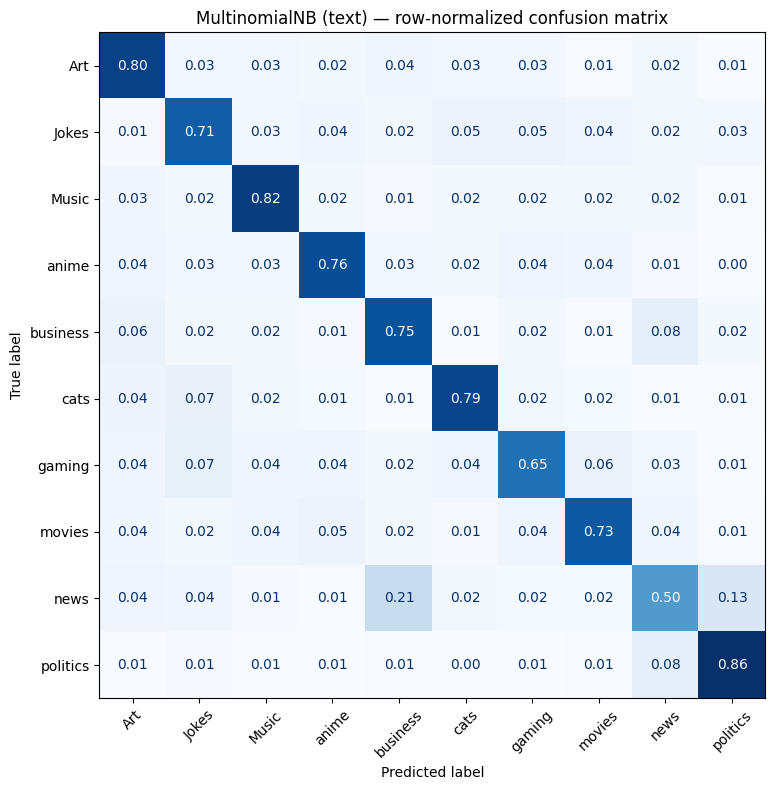

In [ ]:
# Here we have the confusion matrix for the Naive Bayes model.

# As anticipated it never performs better, and matches it only on the classes
# with the most distinctive vocabulary (Music, politics).
# In partitucular suffers a lot in classifying "gaming" posts.
# The reason is always the same: the model is not capable of learning
# dependences among words and gaming is a "multidisciplinary" topic.

# The very interesting thing is however see how both the discriminative model
# and the generative model fail at classifying news, often misclassifying it with
# "business".
# Since this failure is independent on the model we can say that depends on
# the provided dataset.


from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# use the tuned NB; text-only features
nb = MultinomialNB(alpha=0.3).fit(X_train_text, y_train)
nb_pred = nb.predict(X_test_text)

cm = confusion_matrix(y_test, nb_pred, normalize='true')
fig, ax = plt.subplots(figsize=(9, 8))
ConfusionMatrixDisplay(cm, display_labels=le.classes_).plot(
    ax=ax, cmap='Blues', values_format='.2f', xticks_rotation=45, colorbar=False)
plt.title('MultinomialNB (text) — row-normalized confusion matrix')
plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
feat = vectorizer.get_feature_names_out()

# most probable words per class (highest P(word|class))
for i, name in enumerate(le.classes_):
    top = np.argsort(nb.feature_log_prob_[i])[-12:][::-1]
    print(f"{name:10s}: {', '.join(feat[j] for j in top)}")




logprob = nb.feature_log_prob_               # (10, vocab)
avg = logprob.mean(axis=0, keepdims=True)    # mean log-prob across classes
distinctive = logprob - avg                  # how much this class favors each word

print("\nMost DISTINCTIVE words per class (high P(word|class) vs other classes):")
for i, name in enumerate(le.classes_):
    top = np.argsort(distinctive[i])[-12:][::-1]
    print(f"{name:10s}: {', '.join(feat[j] for j in top)}")

Art       : digit, on, the, and, 2019, of, to, my, in, art, acryl, me
Jokes     : the, and, to, you, he, in, of, it, what, is, that, my
Music     : the, to, and, of, music, rock, it, song, in, is, you, this
anime     : the, to, and, of, anim, it, is, in, that, this, for, you
business  : in, to, the, and, for, 2019, of, busi, at, your, march, servic
cats      : the, my, cat, to, and, is, of, she, he, in, this, her
gaming    : the, to, game, and, it, of, is, in, for, you, my, this
movies    : the, and, of, to, movi, in, it, is, that, for, this, film
news      : in, to, of, the, and, for, on, with, is, at, by, news
politics  : to, trump, the, of, in, for, and, on, mueller, is, report, say

Most DISTINCTIVE words per class (high P(word|class) vs other classes):
Art       : acryl, px, canva, watercolor, graphit, a4, pencil, charcoal, ink, untitl, 9x12, a3
Jokes     : bartend, exclaim, repli, condom, lightbulb, bulb, farmer, nun, priest, rabbi, peni, sir
Music     : hiphop, hip, funk, album,

In [ ]:
# Linear Support Vector Machine (Linear SVM)
# This is once yet a linear model, however here we do not use anymore
# the average cross entropy loss function. It is used the hinge loss function.
# The ideal SVM wishes for the classes to be linearly separable.
# If that would be the case we may find an infinity of decision boundary
# hyperplanes properly separating the classes.
# The classifier in that case would identify the hyperplane ensuring
# the largest margin. the margin is the width of the band between the two classes;
# the SVM places the boundary to maximize it. The parallel hyperplanes bounding
# this band pass through the closest training points — the support vectors.
# The points on the margin boundary or violating it (they are inside the margin)
# are the support vectors — they alone determine the hyperplane.
# However we should also account for the samples
# that are not the in the correct side of that hyperplane (that sample would be
# misclassified if we used a maximum margin classifier assuming linearly
# separable classes). It is for this reason that we use the hinge loss
# function. We penalyze in the training those samples.
# At inference time we evaluate wx+b. This is the distance (we actually divide
# by ||w||) of the sample x from the separating hyperplane. More x is further
# from one side and more the model is confident. More it is closer and more the
# model is uncertain. This holds well when we have 2 classes but in this case
# we have 10.
# We have two possible approaches:
# i) one vs the rest: for each class we fit a linear SVM model merging in one
# class all the other classes. In this case we obtain in the end 10 linear SVM
# classifiers. At inference time submit the sample to all the classifiers and
# we chose the specific class with the highest margin (distance from the boundar
# hyperplane);
# ii) one vs one: for all possible class pairs we build a linear SVM classifier.
# In this case we would obtain 45 (binomial coeffiecient with n=10 and k=2)
# classifiers. At inference time we would pick the most voted class.
# Here it is going to be use one vs rest.


from sklearn.svm import LinearSVC
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, f1_score

# tune C on the carried-forward feature set (text+numeric), same discipline as LR
Xtr_nc, Xte_nc = variants['text+numeric']

grid = GridSearchCV(
    LinearSVC(max_iter=5000),            # more iters: SVM can be slower to converge
    {'C': [0.01, 0.03, 0.1, 0.3, 1.0]},  # note: SVM's sweet spot is usually LOWER than LR's
    cv=5, scoring='accuracy', n_jobs=-1,
)
grid.fit(Xtr_nc, y_train)
best_C = grid.best_params_['C']
print("best C:", best_C, "| CV acc:", round(grid.best_score_, 4))

# refit the full ablation with the chosen C
def svm_eval(Xtr, Xte, label, C):
    clf = LinearSVC(C=C, max_iter=5000)
    clf.fit(Xtr, y_train)
    tr = accuracy_score(y_train, clf.predict(Xtr))
    te = accuracy_score(y_test,  clf.predict(Xte))
    f1 = f1_score(y_test, clf.predict(Xte), average='macro')
    print(f"{label:20s}  train={tr:.4f}  test={te:.4f}  macroF1={f1:.4f}")
    return clf

print()
svm_final = None
for name, (Xtr, Xte) in variants.items():
    clf = svm_eval(Xtr, Xte, name, best_C)
    if name == 'text+numeric':
        svm_final = clf

best C: 0.1 | CV acc: 0.7692

text                  train=0.8299  test=0.7591  macroF1=0.7579
text+numeric          train=0.8469  test=0.7789  macroF1=0.7778
text+status           train=0.8485  test=0.7777  macroF1=0.7763
text+numeric+status   train=0.8628  test=0.7974  macroF1=0.7963


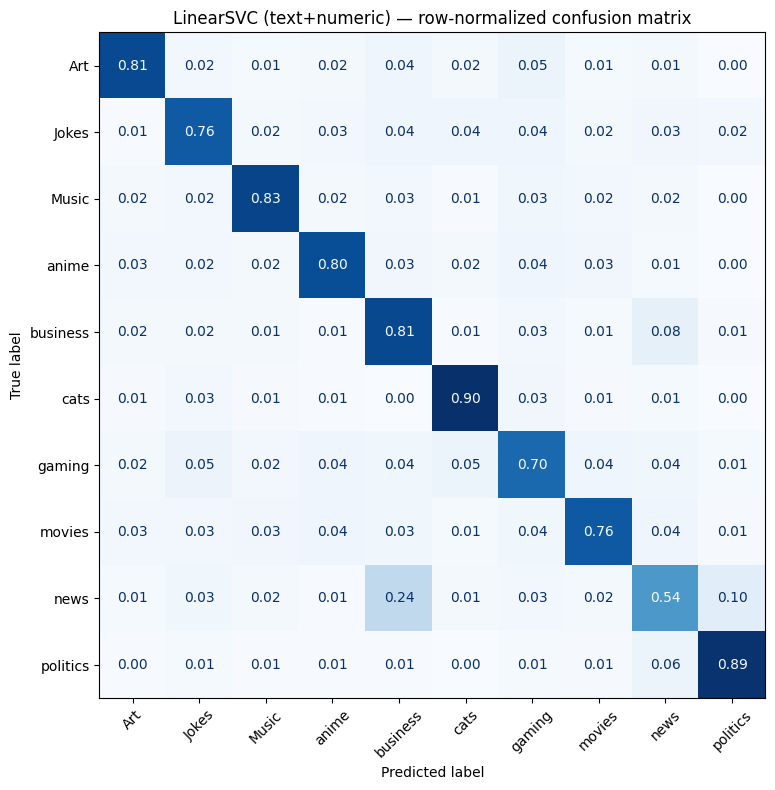

In [ ]:
# Confusion Matrix for linear SVM

# We appreciate the fact that it is slightly superior to LR regarding
# classes already having a high classification rate.
# We can think that those classes are the easiest to separate.
# However it performs slightly poorer regarding the "news" subreddit.
# The "news" class seems to be inherently not separable.

import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# refit the carried-forward SVM (text+numeric, C=0.1)
from sklearn.svm import LinearSVC
Xtr_nc, Xte_nc = variants['text+numeric']
svm = LinearSVC(dual=True, max_iter=2000, C=0.1).fit(Xtr_nc, y_train)

svm_pred = svm.predict(Xte_nc)

# --- confusion matrix ---
cm = confusion_matrix(y_test, svm_pred, normalize='true')
fig, ax = plt.subplots(figsize=(9, 8))
ConfusionMatrixDisplay(cm, display_labels=le.classes_).plot(
    ax=ax, cmap='Blues', values_format='.2f', xticks_rotation=45, colorbar=False)
plt.title('LinearSVC (text+numeric) — row-normalized confusion matrix')
plt.tight_layout()
plt.show()

In [ ]:
# Remember that we are using one vs rest approach. Hence the first high-confidence
# misclassification reads as follows:
#  true     pred     m_pred  m_true
#  gaming   movies    3.99   -0.89
# The classifier with "movies" outputed the highest margin (3.99) among the
# other classes. However the true label was "gaming". The "gaming" classifier
# outputed "-0.89" indicating that the sample was not in the "gaming" region
# but in the other classes region. Please notice that that classifier wasnt so
# sure, in fact since -0.89 is close to 0 it means that x is close to the
# decision boundary where lies the most dubious samples.

# Another interesting case to highlight is the following:
#  true     pred     m_pred  m_true
#  Music    Jokes   -3.79   -7.78
# Both the classifiers placed the post in the other classes region!
# In other terms the post belonged confidently to no class.

scores = svm.decision_function(Xte_nc)        # (10000, 10) margins per class
pred   = scores.argmax(axis=1)

wrong = np.where(pred != y_test)[0]
# confidence = margin the model gave its (wrong) pick, minus the margin it gave the true class
margin_pred = scores[wrong, pred[wrong]]
margin_true = scores[wrong, y_test[wrong]]
conf = margin_pred - margin_true              # bigger = more confidently wrong
order = wrong[np.argsort(conf)[::-1]]

rows = []
for idx in order[:15]:
    rows.append({
        'true':   le.classes_[y_test[idx]],
        'pred':   le.classes_[pred[idx]],
        'm_pred': round(scores[idx, pred[idx]], 2),
        'm_true': round(scores[idx, y_test[idx]], 2),
        'title':  test.iloc[idx]['title'][:80],
    })
pd.set_option('display.max_colwidth', 90)
print(pd.DataFrame(rows).to_string(index=False))

    true     pred  m_pred  m_true                                                                            title
  gaming   movies    3.99   -0.89                                Gaming equivalents to movies that made you think.
business politics    0.78   -4.02 The US House has passed a bill forbidding the government from ever releasing fre
   Jokes   movies    2.62   -2.05                                          Would you go watch Aladdin in theaters?
  movies     cats    3.38   -1.23 CinemaCon 2019: Turns Out The Cats In Tom Hooper’s CATS Are The Size Of Actual C
  movies      Art    2.75   -1.83                          I painted The Ghostbusters 2ft x 3ft Acrylic on Canvas.
    news business    1.95   -2.41 Modern Stainless Steel Bathroom Sinks I Modern double sink vanity I Contemporary
  gaming    Jokes    2.04   -2.31 Cycle Dealers In Powai Mumbai MTB bikes are known by mountain bikes. Mountain bi
  movies    anime    0.98   -3.14                          [Quick question] Plea

In [ ]:
# Multilayer perceptron (MLP)
#
# Now let's approach a modern technique.
# We are going to use a forward deep neural network to solve the classification
# problem.
#
#
#

import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import accuracy_score, f1_score

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("device:", device)

# carry-forward feature set: text + numeric (the honest model)
Xtr_sparse, Xte_sparse = variants['text+numeric']
n_features = Xtr_sparse.shape[1]      # 8126
n_classes  = 10

class SparseDataset(Dataset):
    """Holds a scipy CSR matrix + labels; densifies one row at a time."""
    def __init__(self, X_sparse, y):
        self.X = X_sparse.tocsr()
        self.y = torch.as_tensor(y, dtype=torch.long)
    def __len__(self):
        return self.X.shape[0]
    def __getitem__(self, i):
        row = self.X[i].toarray().ravel()          # densify ONE row (8126 floats)
        return torch.as_tensor(row, dtype=torch.float32), self.y[i]

train_ds = SparseDataset(Xtr_sparse, y_train)
test_ds  = SparseDataset(Xte_sparse, y_test)

train_loader = DataLoader(train_ds, batch_size=256, shuffle=True,  num_workers=2)
test_loader  = DataLoader(test_ds,  batch_size=512, shuffle=False, num_workers=2)

device: cuda


In [ ]:
class MLP(nn.Module):
    def __init__(self, n_in, n_hidden=256, n_out=10, p_drop=0.5):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_in, n_hidden),
            nn.ReLU(),
            nn.Dropout(p_drop),          # regularization — text MLPs overfit fast
            nn.Linear(n_hidden, n_out),  # raw logits; CrossEntropyLoss applies softmax
        )
    def forward(self, x):
        return self.net(x)

model = MLP(n_features).to(device)
print(model)

MLP(
  (net): Sequential(
    (0): Linear(in_features=8126, out_features=256, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.5, inplace=False)
    (3): Linear(in_features=256, out_features=10, bias=True)
  )
)


In [ ]:
criterion = nn.CrossEntropyLoss()                       # expects raw logits + int labels
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)  # weight_decay = L2

def evaluate(loader):
    model.eval()
    preds, trues = [], []
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device)
            logits = model(xb)
            preds.append(logits.argmax(1).cpu().numpy())
            trues.append(yb.numpy())
    preds = np.concatenate(preds); trues = np.concatenate(trues)
    return accuracy_score(trues, preds), f1_score(trues, preds, average='macro'), preds

N_EPOCHS = 15
for epoch in range(1, N_EPOCHS + 1):
    model.train()
    total_loss = 0.0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        loss = criterion(model(xb), yb)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * xb.size(0)

    tr_acc, _, _        = evaluate(train_loader)
    te_acc, te_f1, _    = evaluate(test_loader)
    print(f"epoch {epoch:2d}  loss={total_loss/len(train_ds):.4f}  "
          f"train_acc={tr_acc:.4f}  test_acc={te_acc:.4f}  test_f1={te_f1:.4f}")

    # We are overfitting the training set. Maybe we can do some early stopping
    # to have a slightly more rigid model. This means of course that
    # the nonlinearity provided by the hidden layer offers more advanced
    # representation capabilities at the cost of losing the interpretability.
    # We are capturing word interactions that the linear models cannot.
    #

epoch  1  loss=1.1461  train_acc=0.8023  test_acc=0.7760  test_f1=0.7763
epoch  2  loss=0.6805  train_acc=0.8411  test_acc=0.7951  test_f1=0.7951
epoch  3  loss=0.5874  train_acc=0.8613  test_acc=0.7993  test_f1=0.7990
epoch  4  loss=0.5370  train_acc=0.8749  test_acc=0.8016  test_f1=0.8016
epoch  5  loss=0.5014  train_acc=0.8850  test_acc=0.8009  test_f1=0.8008
epoch  6  loss=0.4725  train_acc=0.8939  test_acc=0.8023  test_f1=0.8025
epoch  7  loss=0.4480  train_acc=0.8997  test_acc=0.8018  test_f1=0.8017
epoch  8  loss=0.4309  train_acc=0.9084  test_acc=0.8037  test_f1=0.8037
epoch  9  loss=0.4135  train_acc=0.9138  test_acc=0.8017  test_f1=0.8014
epoch 10  loss=0.3952  train_acc=0.9195  test_acc=0.8037  test_f1=0.8037
epoch 11  loss=0.3805  train_acc=0.9236  test_acc=0.8041  test_f1=0.8043
epoch 12  loss=0.3685  train_acc=0.9276  test_acc=0.8046  test_f1=0.8047
epoch 13  loss=0.3591  train_acc=0.9309  test_acc=0.8033  test_f1=0.8029
epoch 14  loss=0.3454  train_acc=0.9364  test_acc=0

In [ ]:
# Early stopping tuning

from sklearn.model_selection import train_test_split

# carve a validation set FROM TRAIN (never touch test for model selection)
idx_tr, idx_val = train_test_split(np.arange(Xtr_sparse.shape[0]),
                                   test_size=0.1, stratify=y_train, random_state=0)
tr_ds  = SparseDataset(Xtr_sparse[idx_tr],  y_train[idx_tr])
val_ds = SparseDataset(Xtr_sparse[idx_val], y_train[idx_val])
tr_loader  = DataLoader(tr_ds,  batch_size=256, shuffle=True,  num_workers=2)
val_loader = DataLoader(val_ds, batch_size=512, shuffle=False, num_workers=2)

model = MLP(n_features).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)

best_val, best_state, patience, wait = 0.0, None, 3, 0
for epoch in range(1, 31):
    model.train()
    for xb, yb in tr_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        loss = criterion(model(xb), yb)
        loss.backward(); optimizer.step()

    val_acc, _, _ = evaluate(val_loader)
    if val_acc > best_val:
        best_val, best_state, wait = val_acc, {k: v.cpu().clone() for k, v in model.state_dict().items()}, 0
    else:
        wait += 1
        if wait >= patience:
            print(f"early stop at epoch {epoch}, best val_acc={best_val:.4f}")
            break

model.load_state_dict(best_state)   # restore best-validation weights
test_acc, test_f1, mlp_pred = evaluate(test_loader)
print(f"final MLP  test_acc={test_acc:.4f}  test_f1={test_f1:.4f}")

early stop at epoch 12, best val_acc=0.8040
final MLP  test_acc=0.7976  test_f1=0.7977


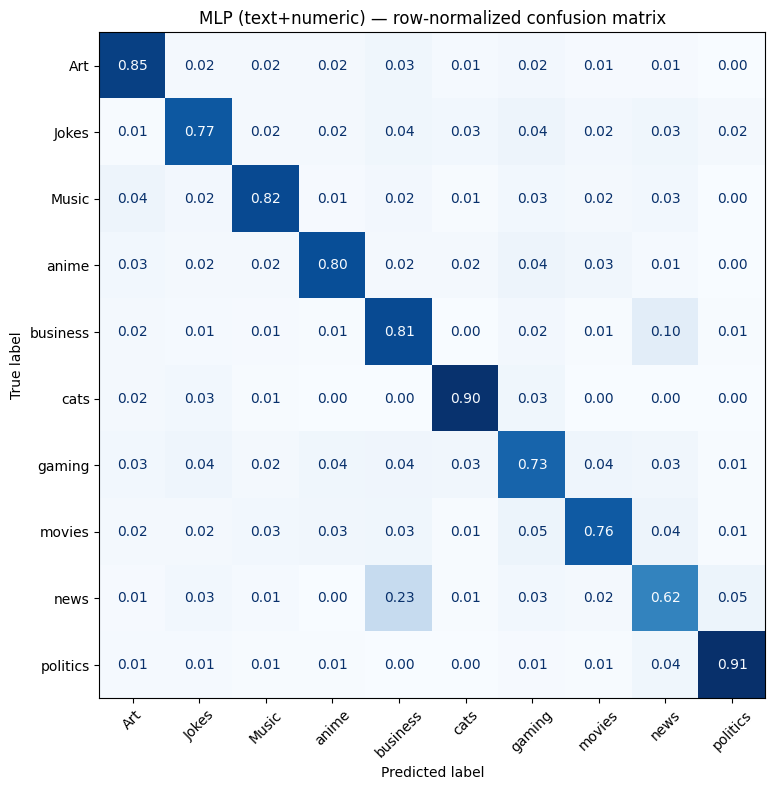

In [ ]:
# Confusion Matrix for MLP
# Every classification accuracy is better or remains the same compared to the
# best linear model (linear SVM). Notice the gain in "gaming" compared to it where
# linear SVM is in relatively great difficult.
# Also again "news" leaks in "business" confirming the problem is in the data.

import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# --- confusion matrix ---
cm = confusion_matrix(y_test, mlp_pred, normalize='true')
fig, ax = plt.subplots(figsize=(9, 8))
ConfusionMatrixDisplay(cm, display_labels=le.classes_).plot(
    ax=ax, cmap='Blues', values_format='.2f', xticks_rotation=45, colorbar=False)
plt.title('MLP (text+numeric) — row-normalized confusion matrix')
plt.tight_layout()
plt.show()